# Dataset 1: Eurostat Gross Value Added (GVA) Analysis
## Notebook Overview

This notebook focuses on the collection, processing, and analysis of **Gross Value Added (GVA)** data from Eurostat. GVA is a key economic indicator that measures each sector's contribution to the overall economy.


## Data Source Information

**Dataset:** `nama_10_a10` (National Accounts - Aggregated by Industry)  
**Source:** Eurostat National Accounts  
**URL:** https://ec.europa.eu/eurostat/databrowser/view/nama_10_a10  
**Coverage:** EU Member States, 2010-2024  
**Frequency:** Annual  
**Unit:** Chain Linked Volumes (2015 prices), Million EUR

### Sectors  

- **B-E:** Industry (Mining + Manufacturing + Energy + Water supply)
- **C:** Manufacturing only
- **TOTAL:** All NACE activities (total economy)

### Countries Analyzed (EU-6)

- **DE:** Germany
- **FR:** France
- **IT:** Italy
- **PL:** Poland
- **ES:** Spain
- **NL:** Netherlands



## 1. Setup and Configuration

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

COUNTRIES = {
    'DE': 'Germany',
    'FR': 'France',
    'IT': 'Italy',
    'PL': 'Poland',
    'ES': 'Spain',
    'NL': 'Netherlands'
}

START_YEAR = 2010
END_YEAR = 2024


DATA_PATH = '../../data/raw/'

## 2. Data Loading

In [7]:
try:
    df_gva = pd.read_csv(f'{DATA_PATH}eurostat_gva.csv')
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Error: Data file not found!")

Data loaded successfully!


## 3. Data Structure and Quality Assessment

In [8]:
display(df_gva.head(10))

,country_code,country,year,gva_industry_meur,gva_manufacturing_meur,gva_total_meur,industry_share_pct,manufacturing_share_pct,industry_yoy_growth_pct
0,DE,Germany,2010,617890.80,544972.80,2534283.90,24.38,21.50,NaN
1,DE,Germany,2011,650943.30,594104.70,2629245.30,24.76,22.60,5.35
2,DE,Germany,2012,653401.70,583777.20,2642528.60,24.73,22.09,0.38
3,DE,Germany,2013,645616.60,583471.70,2654681.40,24.32,21.98,-1.19
4,DE,Germany,2014,675869.30,615920.70,2714315.00,24.90,22.69,4.69
5,DE,Germany,2015,684747.00,621665.00,2753317.00,24.87,22.58,1.31
6,DE,Germany,2016,711585.10,645864.30,2816907.30,25.26,22.93,3.92
7,DE,Germany,2017,736715.90,667252.50,2898585.40,25.42,23.02,3.53
8,DE,Germany,2018,744159.60,675624.50,2933913.30,25.36,23.03,1.01
9,DE,Germany,2019,737467.10,666152.60,2953979.60,24.97,22.55,-0.90


In [9]:
print(df_gva.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country_code             90 non-null     object 
 1   country                  90 non-null     object 
 2   year                     90 non-null     int64  
 3   gva_industry_meur        90 non-null     float64
 4   gva_manufacturing_meur   90 non-null     float64
 5   gva_total_meur           90 non-null     float64
 6   industry_share_pct       90 non-null     float64
 7   manufacturing_share_pct  90 non-null     float64
 8   industry_yoy_growth_pct  84 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 6.5+ KB
None


### Check for missing values

In [12]:
missing = df_gva.isnull().sum()
missing_pct = (missing / len(df_gva) * 100).round(2)

if missing.sum() == 0:
    print("No missing values found ")
else:
    print(f"\n Total Missing values: {missing.sum()}")
    print(f"\n Total Missing %: {missing_pct}")


 Total Missing values: 6

 Total Missing %: country_code              0.00
country                   0.00
year                      0.00
gva_industry_meur         0.00
gva_manufacturing_meur    0.00
gva_total_meur            0.00
industry_share_pct        0.00
manufacturing_share_pct   0.00
industry_yoy_growth_pct   6.67
dtype: float64


### Summary statistics

In [13]:
display(df_gva.describe().round(2))

SUMMARY STATISTICS


,year,gva_industry_meur,gva_manufacturing_meur,gva_total_meur,industry_share_pct,manufacturing_share_pct,industry_yoy_growth_pct
count,90.00,90.00,90.00,90.00,90.00,90.00,84.00
mean,2017.00,269758.20,231533.66,1411730.92,18.87,15.49,0.98
std,4.34,204035.44,192348.97,829213.33,4.60,4.20,4.26
min,2010.00,84240.00,61076.60,329714.20,11.78,10.85,-12.06
25%,2013.00,112281.20,90864.75,660326.75,15.28,11.80,-0.80
50%,2017.00,212126.90,177635.05,1302386.50,17.37,14.08,1.05
75%,2021.00,286408.38,243436.00,1970320.82,24.24,19.39,3.52
max,2024.00,744159.60,680146.60,3004851.80,26.51,23.03,14.61


## 4. Exploratory Data Analysis (EDA)

### 4.1 Time Series Analysis: Industrial GVA Evolution

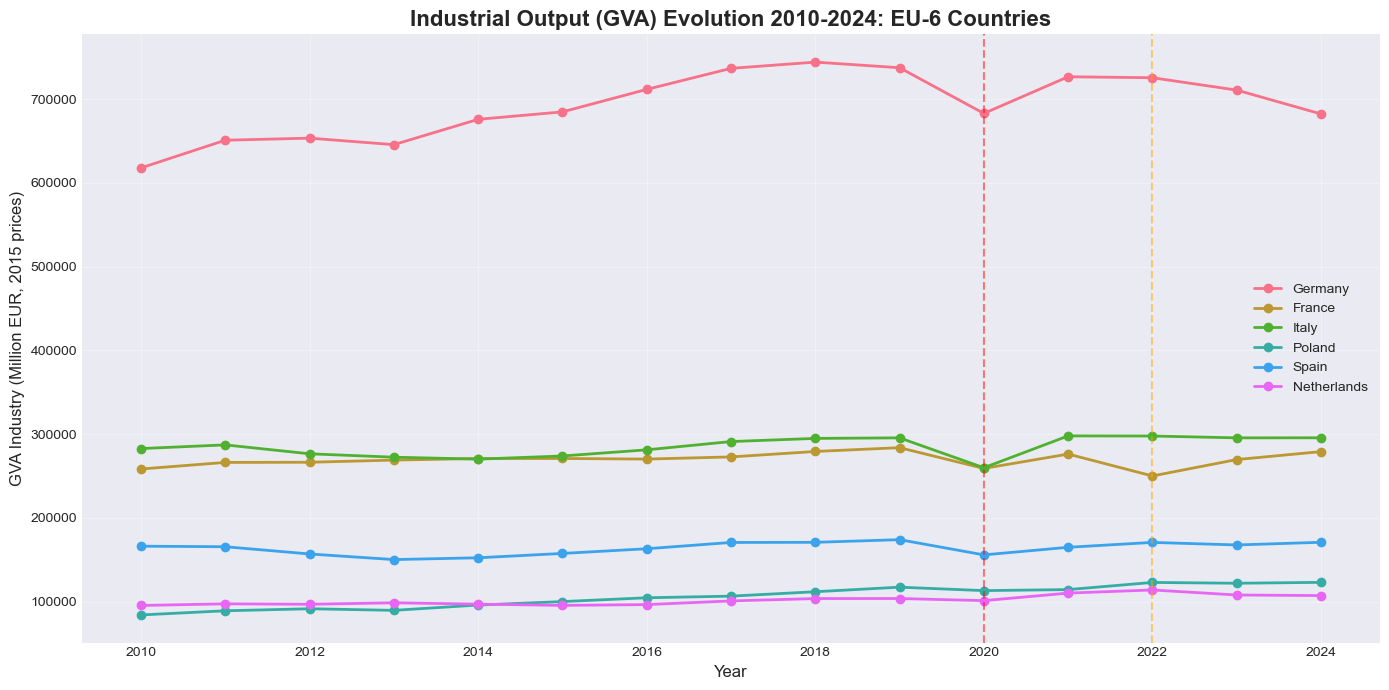

In [15]:

plt.figure(figsize=(14, 7))

for country in COUNTRIES.values():
    data = df_gva[df_gva['country'] == country]
    plt.plot(data['year'], data['gva_industry_meur'], 
             marker='o', linewidth=2, label=country)

plt.title('Industrial Output (GVA) Evolution 2010-2024: EU-6 Countries', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('GVA Industry (Million EUR, 2015 prices)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.5, label='COVID-19')
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5, label='Energy Crisis')
plt.tight_layout()
plt.show()

### KEY OBSERVATIONS:
<ol>
 <li>Germany maintains the highest industrial output throughout the period</li>
 <li>Visible COVID-19 impact in 2020 across all countries</li>
 <li>Post-2022 divergence: Germany shows stagnation/decline, while Poland shows growth</li>
    <li>This divergence coincides with the EU ETS high-price regime (carbon price >€50)</li>
 </ol>

### 4.2 Manufacturing vs Total Industry Comparison

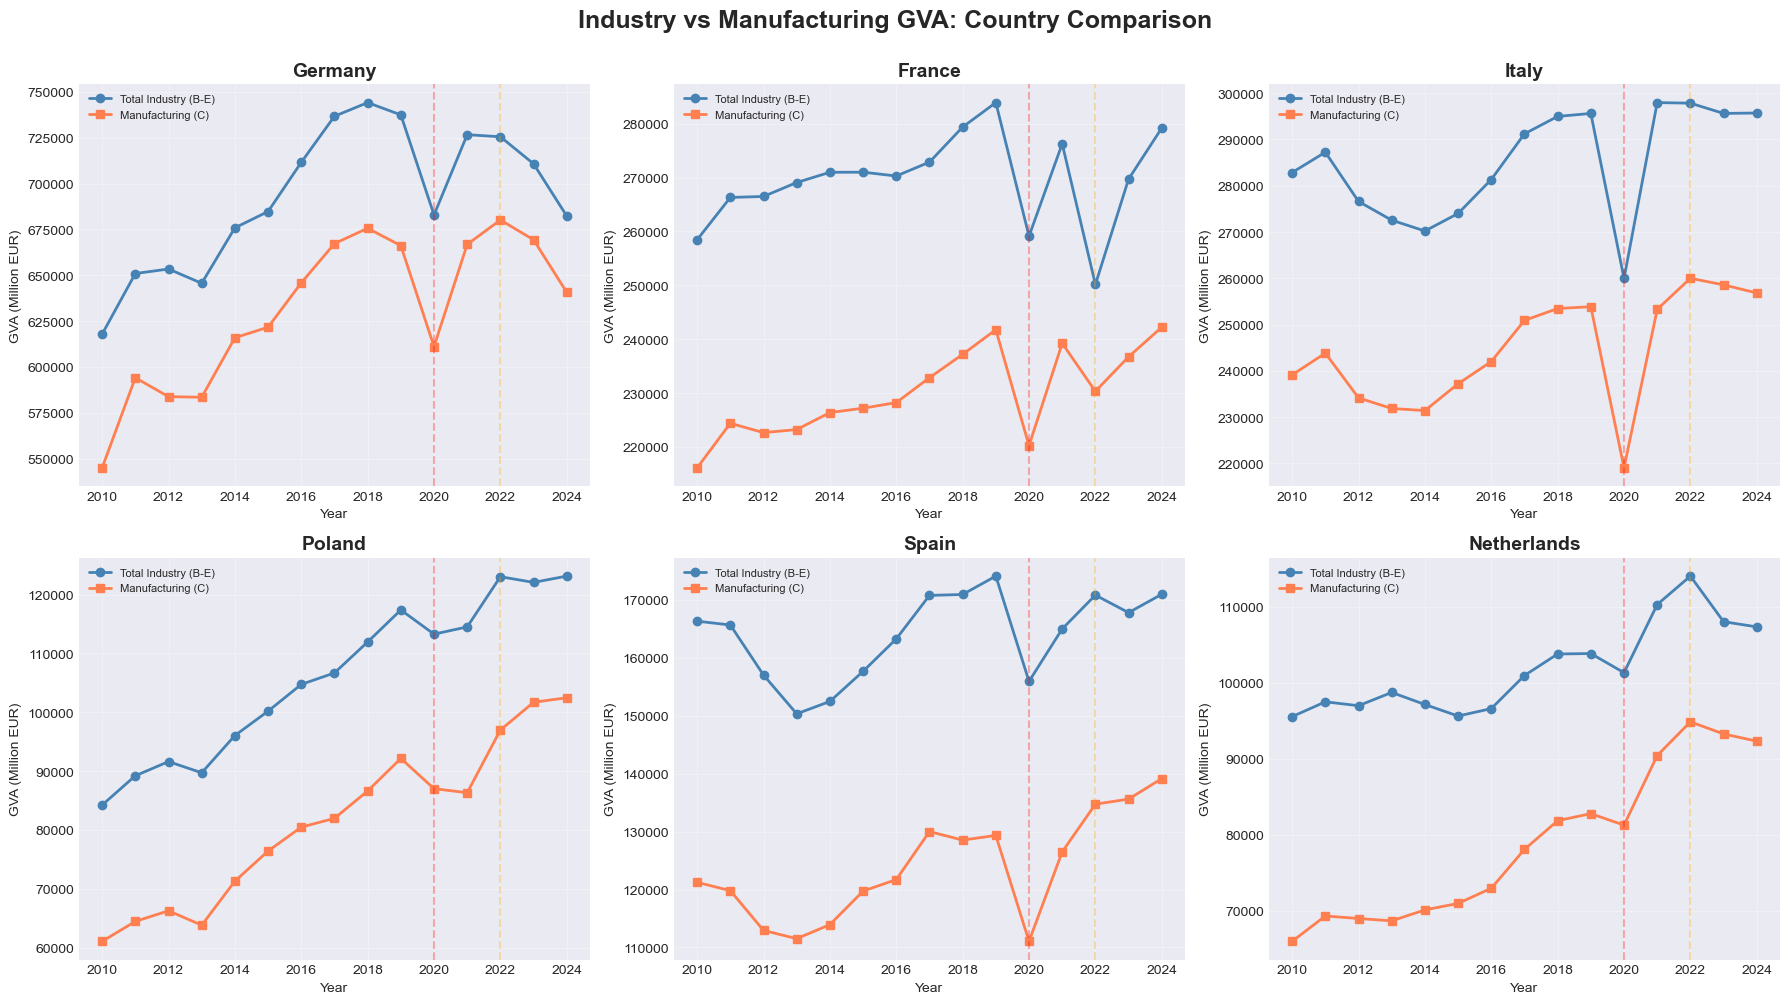

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, country in enumerate(COUNTRIES.values()):
    data = df_gva[df_gva['country'] == country]
    
    ax = axes[idx]
    ax.plot(data['year'], data['gva_industry_meur'], 
            marker='o', linewidth=2, label='Total Industry (B-E)', color='steelblue')
    ax.plot(data['year'], data['gva_manufacturing_meur'], 
            marker='s', linewidth=2, label='Manufacturing (C)', color='coral')
    
    ax.set_title(f'{country}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('GVA (Million EUR)', fontsize=10)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=2020, color='red', linestyle='--', alpha=0.3)
    ax.axvline(x=2022, color='orange', linestyle='--', alpha=0.3)

plt.suptitle('Industry vs Manufacturing GVA: Country Comparison', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### KEY OBSERVATIONS:
<ol>
 <li>Manufacturing (C) represents the core industrial sector directly affected by ETS</li>
 <li>Total Industry (B-E) includes energy generation, which is also carbon-intensive</li>
 <li>Gap between lines shows contribution of mining, energy, and utilities</li>
 </ol>

### 4.3 Industry Share Analysis: Deindustrialization Indicator

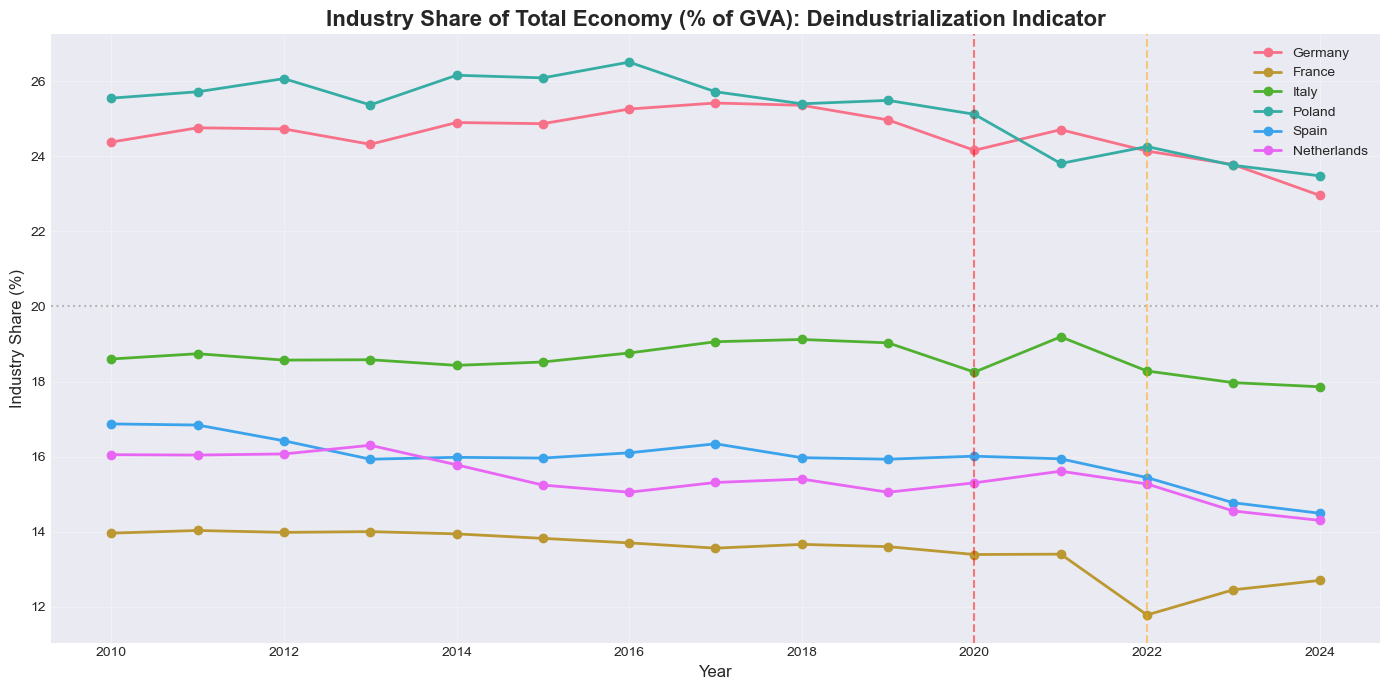

In [21]:
plt.figure(figsize=(14, 7))

for country in COUNTRIES.values():
    data = df_gva[df_gva['country'] == country]
    plt.plot(data['year'], data['industry_share_pct'], 
             marker='o', linewidth=2, label=country)

plt.title('Industry Share of Total Economy (% of GVA): Deindustrialization Indicator', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Industry Share (%)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=20, color='gray', linestyle=':', alpha=0.5, label='20% threshold')
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Deindustrialization Analysis

A declining industry share indicates:
<ol>
     <li>Structural economic transformation (services growing faster)</li>
     <li>Industrial decline (absolute contraction)</li>
 </ol>
To distinguish:
<ol>
     <li>If GVA_total grows and industry_share declines → Structural transformation (services boom)</li>
     <li>If GVA_total stagnates and industry_share declines → Deindustrialization</li>
 </ol>





### 4.4 Year-over-Year Growth Rate Analysis

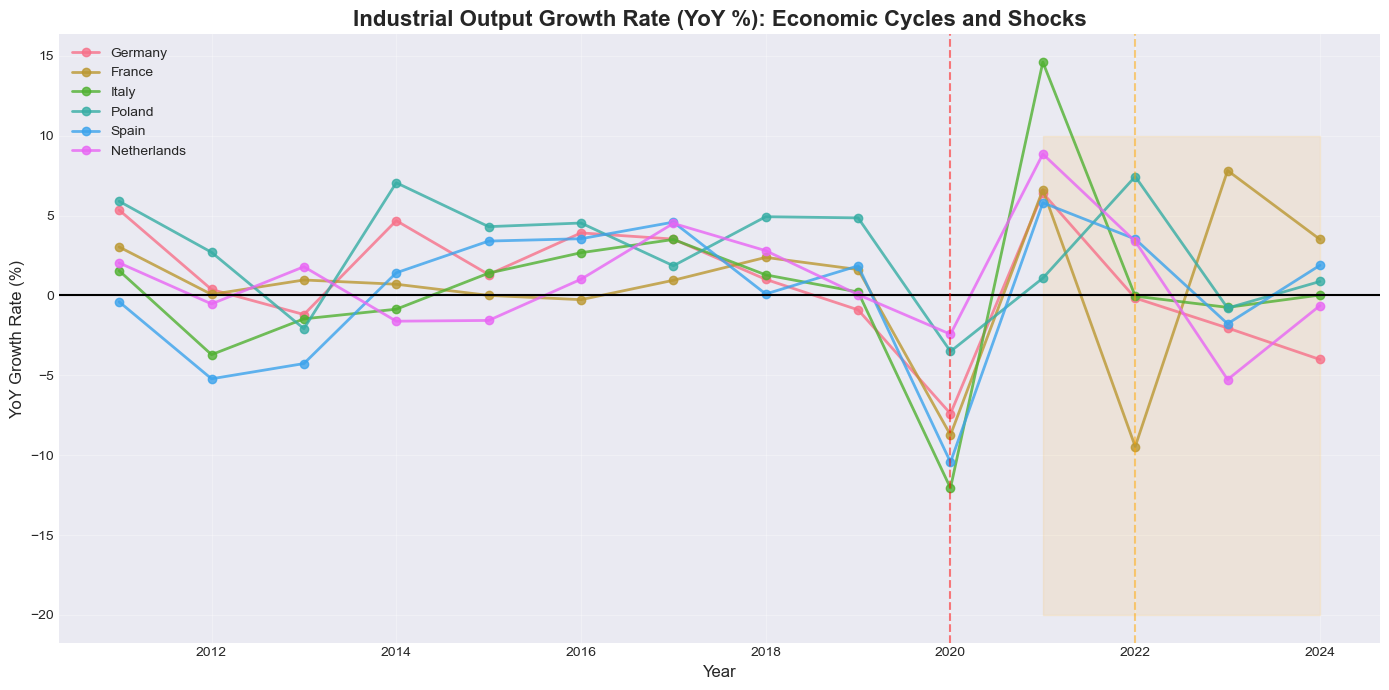


GROWTH RATE INSIGHTS:
- Negative growth in 2020: COVID-19 pandemic shock
- 2021: V-shaped recovery
- 2022-2024: Divergence during high carbon price regime
  * Germany: Negative/stagnant growth
  * Poland: Continued growth (structural catch-up effect?)


In [19]:
# Plot: YoY growth rates
plt.figure(figsize=(14, 7))

for country in COUNTRIES.values():
    data = df_gva[df_gva['country'] == country]
    plt.plot(data['year'], data['industry_yoy_growth_pct'], 
             marker='o', linewidth=2, label=country, alpha=0.8)

plt.title('Industrial Output Growth Rate (YoY %): Economic Cycles and Shocks', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('YoY Growth Rate (%)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.5, label='COVID-19')
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5, label='Energy Crisis')
plt.fill_between([2021, 2024], -20, 10, alpha=0.1, color='orange', label='High Carbon Price Era')
plt.tight_layout()
plt.show()

### GROWTH RATE INSIGHTS:
<ol>
     <li>Negative growth in 2020: COVID-19 pandemic shock</li>
     <li>2021: V-shaped recovery</li>
     <li>2022-2024: Divergence during high carbon price regime</li>

 </ol>
  * Germany: Negative/stagnant growth
  * Poland: Continued growth 


## 5. Comparative Analysis: 2010 vs 2024

### 5.1 Absolute Change in Industrial Output

INDUSTRIAL OUTPUT CHANGE: 2010 vs 2024


,country,gva_2010,gva_2024,absolute_change,percent_change
5,Poland,84240.00,123142.10,38902.10,46.18
4,Netherlands,95552.80,107367.30,11814.50,12.36
0,Germany,617890.80,682288.50,64397.70,10.42
2,France,258461.50,279194.40,20732.90,8.02
3,Italy,282850.00,295702.20,12852.20,4.54
1,Spain,166319.20,170966.80,4647.60,2.79


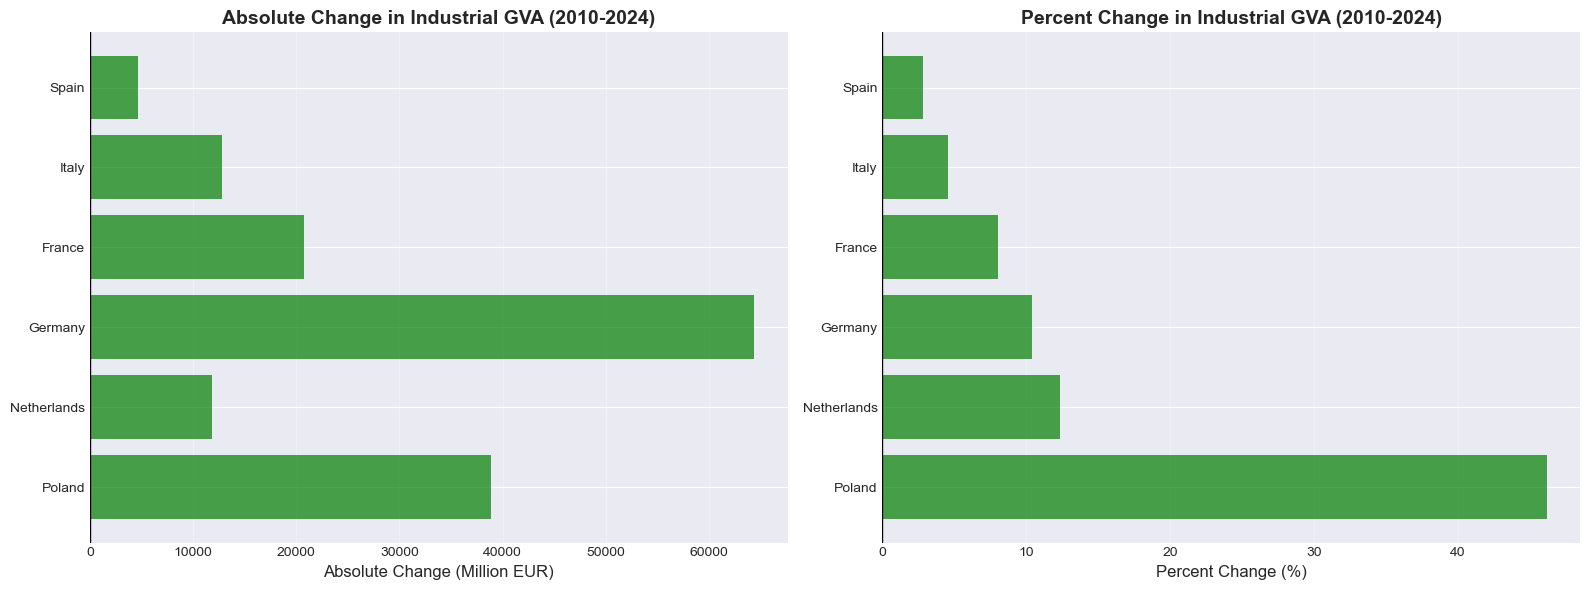


WINNERS AND LOSERS (2010-2024):
- Growth: Poland (structural catch-up, lower baseline carbon costs)
- Decline: Germany, Netherlands (high exposure to ETS, energy-intensive sectors)
- This pattern is consistent with the 'Pollution Haven Hypothesis'


In [20]:
# Calculate 2010 vs 2024 change
df_2010 = df_gva[df_gva['year'] == 2010][['country', 'gva_industry_meur']].rename(
    columns={'gva_industry_meur': 'gva_2010'})
df_2024 = df_gva[df_gva['year'] == 2024][['country', 'gva_industry_meur']].rename(
    columns={'gva_industry_meur': 'gva_2024'})

df_change = df_2010.merge(df_2024, on='country')
df_change['absolute_change'] = df_change['gva_2024'] - df_change['gva_2010']
df_change['percent_change'] = (df_change['absolute_change'] / df_change['gva_2010'] * 100).round(2)
df_change = df_change.sort_values('percent_change', ascending=False)

print("=" * 80)
print("INDUSTRIAL OUTPUT CHANGE: 2010 vs 2024")
print("=" * 80)
display(df_change)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: Absolute change
colors = ['green' if x > 0 else 'red' for x in df_change['absolute_change']]
axes[0].barh(df_change['country'], df_change['absolute_change'], color=colors, alpha=0.7)
axes[0].set_xlabel('Absolute Change (Million EUR)', fontsize=12)
axes[0].set_title('Absolute Change in Industrial GVA (2010-2024)', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].grid(axis='x', alpha=0.3)

# Bar chart: Percent change
colors = ['green' if x > 0 else 'red' for x in df_change['percent_change']]
axes[1].barh(df_change['country'], df_change['percent_change'], color=colors, alpha=0.7)
axes[1].set_xlabel('Percent Change (%)', fontsize=12)
axes[1].set_title('Percent Change in Industrial GVA (2010-2024)', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("""\nWINNERS AND LOSERS (2010-2024):
- Growth: Poland (structural catch-up, lower baseline carbon costs)
- Decline: Germany, Netherlands (high exposure to ETS, energy-intensive sectors)
- This pattern is consistent with the 'Pollution Haven Hypothesis'""")

### 5.2 Country Performance Ranking

In [ ]:
# Calculate average annual growth rate (CAGR)
def calculate_cagr(start_value, end_value, years):
    return (((end_value / start_value) ** (1 / years)) - 1) * 100

cagr_results = []
for country in COUNTRIES.values():
    data = df_gva[df_gva['country'] == country].sort_values('year')
    start_val = data[data['year'] == 2010]['gva_industry_meur'].values[0]
    end_val = data[data['year'] == 2024]['gva_industry_meur'].values[0]
    cagr = calculate_cagr(start_val, end_val, 14)
    
    cagr_results.append({
        'Country': country,
        'GVA_2010': start_val,
        'GVA_2024': end_val,
        'CAGR_%': round(cagr, 3)
    })

df_cagr = pd.DataFrame(cagr_results).sort_values('CAGR_%', ascending=False)

print("=" * 80)
print("COMPOUND ANNUAL GROWTH RATE (CAGR) 2010-2024")
print("=" * 80)
display(df_cagr)

# Visualization
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in df_cagr['CAGR_%']]
plt.barh(df_cagr['Country'], df_cagr['CAGR_%'], color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('CAGR (%)', fontsize=12)
plt.title('Industrial Output Growth: Compound Annual Growth Rate (2010-2024)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("""\nIMPLICATIONS FOR RESEARCH GOALS:
Goal 1 (Regulatory Drag): Countries with negative CAGR warrant detailed investigation
Goal 3 (Valley of Death): Compare 2010-2019 vs 2021-2024 CAGR to isolate high-price era impact""")

## 6. Key Findings and Summary

### Main Observations:

1. **Heterogeneous Impact:** Industrial output changes vary significantly across EU-6 countries (2010-2024)

2. **German Decline:** Germany, the largest industrial economy, shows concerning stagnation/decline post-2021

3. **Polish Growth:** Poland maintains positive growth trajectory despite carbon pricing regime

4. **COVID Recovery:** All countries showed V-shaped recovery in 2021

5. **Post-2021 Divergence:** The period of highest carbon prices (€50+) coincides with industrial divergence

## 7. Data Export for Further Analysis

In [30]:
# Export summary statistics
output_path = '../../data/processed/datasets/'

# Create summary table
summary_stats = df_gva.groupby('country').agg({
    'gva_industry_meur': ['mean', 'std', 'min', 'max'],
    'industry_share_pct': ['mean', 'min', 'max'],
    'industry_yoy_growth_pct': ['mean', 'std']
}).round(2)
display(summary_stats)
try:
    summary_stats.to_csv(f'{output_path}gva_summary_statistics.csv')
    df_change.to_csv(f'{output_path}gva_2010_2024_change.csv', index=False)
    df_cagr.to_csv(f'{output_path}gva_cagr_analysis.csv', index=False)
except:
    print("Error")

gva_industry_meur                              industry_share_pct  \
                         mean      std       min       max               mean   
country                                                                         
France              269551.13  8804.20 250153.00 283920.70              13.46   
Germany             692436.48 38872.55 617890.80 744159.60              24.58   
Italy               284911.12 12025.54 259968.00 297953.50              18.60   
Netherlands         101860.54  5845.74  95552.80 114053.00              15.42   
Poland              105855.48 13348.81  84240.00 123142.10              25.23   
Spain               163934.47  7505.54 150330.50 174100.80              15.93   

                        industry_yoy_growth_pct       
              min   max                    mean  std  
country                                               
France      11.78 14.03                    0.66 4.78  
Germany     22.96 25.42                    0.78 3.83  
Italy       17.86 19.19                    0.46 5.54  
Netherlands 14.30 16.30                    0.89 3.45  
Poland      23.48 26.51                    2.80 3.37  
Spain       14.49 16.87                    0.29 4.45

Error


## 8. Conclusions

This notebook provides a comprehensive analysis of **Gross Value Added (GVA)** trends across six major EU economies from 2010 to 2024. The data reveals:

1. **Divergent trajectories:** Industrial output changes vary significantly, suggesting country-specific factors are at play

2. **Temporal patterns:** The post-2021 period shows distinct behavior, coinciding with the high carbon price regime

3. **Structural questions:** Are we observing:
   - Regulatory drag from carbon pricing?
   - Natural structural transformation (deindustrialization)?
   - Energy crisis shock?
   - Or a combination of all three?

**To answer these questions rigorously, we need to:**
- Integrate carbon price data (next notebook)
- Control for inflation and energy costs
- Apply econometric methods (fixed-effects regression)

The GVA dataset serves as the **dependent variable** in our econometric model, where carbon prices are the primary **independent variable** of interest.